# ECLAT Laptos

# Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
from collections import defaultdict

# Clases

In [2]:
from src.utils import path

# Funciones

In [3]:
def build_vertical_db(transactions):
    """Construye la base de datos vertical (TID-list) a partir de las transacciones."""
    vertical_db = defaultdict(set)
    for tid, transaction in enumerate(transactions):
        for item in transaction:
            vertical_db[frozenset([item])].add(tid)
    return dict(vertical_db)


def eclat(prefix, items, min_support, frequent_itemsets, n_transactions):
    """Búsqueda recursiva en profundidad de itemsets frecuentes."""
    while items:
        item, tid_set = items.pop(0)
        new_prefix = prefix | item
        support = len(tid_set)

        if support >= min_support:
            frequent_itemsets[new_prefix] = {
                "support_count": support,
                "support_pct": round(support / n_transactions, 4),
            }
            suffix = []
            for other_item, other_tid_set in items:
                new_tid_set = tid_set & other_tid_set
                if len(new_tid_set) >= min_support:
                    suffix.append((other_item, new_tid_set))
            if suffix:
                eclat(new_prefix, suffix, min_support,
                      frequent_itemsets, n_transactions)


def run_eclat(transactions, min_support=0.3):
    """Ejecuta ECLAT y devuelve los itemsets frecuentes."""
    n = len(transactions)
    min_sup_count = max(1, int(min_support * n))
    vertical_db = build_vertical_db(transactions)

    frequent_1 = {
        item: tids
        for item, tids in vertical_db.items()
        if len(tids) >= min_sup_count
    }

    frequent_itemsets = {
        item: {"support_count": len(tids),
               "support_pct": round(len(tids) / n, 4)}
        for item, tids in frequent_1.items()
    }

    items_list = sorted(frequent_1.items(), key=lambda x: str(sorted(x[0])))
    eclat(frozenset(), items_list, min_sup_count, frequent_itemsets, n)
    return frequent_itemsets


def generate_rules(frequent_itemsets, min_confidence=0.6):
    """Genera reglas de asociación a partir de los itemsets frecuentes."""
    rules = []
    for itemset, stats in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        for size in range(1, len(itemset)):
            for antecedent in combinations(sorted(itemset), size):
                antecedent = frozenset(antecedent)
                consequent = itemset - antecedent
                if antecedent in frequent_itemsets:
                    ant_sup = frequent_itemsets[antecedent]["support_count"]
                    confidence = stats["support_count"] / ant_sup
                    if confidence >= min_confidence:
                        con_sup_pct = frequent_itemsets.get(
                            consequent, {}).get("support_pct")
                        lift = round(confidence / con_sup_pct, 4) \
                            if con_sup_pct else None
                        rules.append({
                            "antecedents": set(antecedent),
                            "consequents": set(consequent),
                            "support":     stats["support_pct"],
                            "confidence":  round(confidence, 4),
                            "lift":        lift,
                        })
    return sorted(rules, key=lambda r: r["confidence"], reverse=True)


def results_to_df(frequent_itemsets, rules):
    """Convierte los resultados a DataFrames de pandas."""
    df_items = pd.DataFrame([
        {
            "itemset": ", ".join(sorted(k)),
            "tamaño":  len(k),
            "support_count": v["support_count"],
            "support": v["support_pct"],
        }
        for k, v in frequent_itemsets.items()
    ]).sort_values(["tamaño", "support_count"], ascending=[True, False])

    df_rules = pd.DataFrame([
        {
            "antecedents": frozenset(r["antecedents"]),
            "consequents": frozenset(r["consequents"]),
            "support":     r["support"],
            "confidence":  r["confidence"],
            "lift":        r["lift"],
        }
        for r in rules
    ])

    return df_items, df_rules

# Lectura de DF procesado

In [4]:
directorio_proyecto = path.obtener_ruta_local()
datos = pd.read_csv(directorio_proyecto+'\\data\\procesed\\datos_laptos.csv',delimiter = ',',decimal = ".", encoding='utf-8')
datos.head()

,Nombre,Paquete de Ventas,Caracteristicas
0,ASUS ROG Strix SCAR 17 Core i9 12th Gen - (32 ...,"Laptop, Power Adaptor, User Guide, Warranty Do...","Off Black,Gaming Laptop,Gaming,Intel,Core i9,3..."
1,ASUS ROG Strix SCAR 15 Core i9 12th Gen - (32 ...,"Laptop, Power Adaptor, User Guide, Warranty Do...","Off Black,Gaming Laptop,Gaming,Intel,Core i9,3..."
2,HP Victus Ryzen 7 Octa Core 5800H - (16 GB/512...,"Laptop, battery, adapter, cables and user manuals","Mica Silver,Gaming Laptop,Gaming,AMD,Ryzen 7 O..."
3,Lenovo IdeaPad Gaming 3i Ryzen 7 Octa Core R7-...,"Laptop, Power Adaptor, User Guide, Warranty Do...","Shadow Black,Gaming Laptop,Gaming,AMD,Ryzen 7 ..."
4,Lenovo Yoga Slim 7 Core i5 11th Gen - (16 GB/5...,"Laptop, Adaptor","Slate Grey,Thin and Light Laptop,Processing & ..."


## ECLAT con columna Paquete de Ventas

In [5]:
df_paquete_ventas = datos[["Paquete de Ventas"]]
df_paquete_ventas.head()

,Paquete de Ventas
0,"Laptop, Power Adaptor, User Guide, Warranty Do..."
1,"Laptop, Power Adaptor, User Guide, Warranty Do..."
2,"Laptop, battery, adapter, cables and user manuals"
3,"Laptop, Power Adaptor, User Guide, Warranty Do..."
4,"Laptop, Adaptor"


In [6]:
df_paquete_ventas.shape

(984, 1)

In [7]:
data_paquete = list(
    df_paquete_ventas["Paquete de Ventas"].apply(lambda x: [i.strip() for i in str(x).split(",")])
)
data_paquete[:3]

[['Laptop', 'Power Adaptor', 'User Guide', 'Warranty Documents'],
 ['Laptop', 'Power Adaptor', 'User Guide', 'Warranty Documents'],
 ['Laptop', 'battery', 'adapter', 'cables and user manuals']]

In [8]:
# Establezca un valor umbral para el soporte mínimo y ejecute ECLAT
frequent_itemsets_paquete = run_eclat(data_paquete, min_support=0.5)
df_itemsets_paquete, _ = results_to_df(frequent_itemsets_paquete, [])
df_itemsets_paquete

,itemset,tamaño,support_count,support
0,Laptop,1,923,0.9380
2,User Guide,1,632,0.6423
1,Power Adaptor,1,560,0.5691
3,Warranty Documents,1,543,0.5518
6,"Laptop, User Guide",2,602,0.6118
9,"Power Adaptor, User Guide",2,554,0.5630
12,"User Guide, Warranty Documents",2,543,0.5518
4,"Laptop, Power Adaptor",2,541,0.5498
8,"Laptop, Warranty Documents",2,513,0.5213
11,"Power Adaptor, Warranty Documents",2,492,0.5000


In [9]:
# Reglas de asociación con umbral de confianza mínima
rules_paquete = generate_rules(frequent_itemsets_paquete, min_confidence=0.5)
_, df_ar_paquete = results_to_df(frequent_itemsets_paquete, rules_paquete)
df_ar_paquete

,antecedents,consequents,support,confidence,lift
0,"frozenset({Warranty Documents, Laptop})",frozenset({User Guide}),0.5213,1.0000,1.5569
1,"frozenset({Power Adaptor, Warranty Documents})",frozenset({User Guide}),0.5000,1.0000,1.5569
2,frozenset({Warranty Documents}),frozenset({User Guide}),0.5518,1.0000,1.5569
3,frozenset({Power Adaptor}),frozenset({User Guide}),0.5630,0.9893,1.5402
4,"frozenset({Power Adaptor, Laptop})",frozenset({User Guide}),0.5437,0.9889,1.5396
5,frozenset({Power Adaptor}),frozenset({Laptop}),0.5498,0.9661,1.0299
6,"frozenset({Power Adaptor, User Guide})",frozenset({Laptop}),0.5437,0.9657,1.0295
7,frozenset({Power Adaptor}),"frozenset({User Guide, Laptop})",0.5437,0.9554,1.5616
8,frozenset({User Guide}),frozenset({Laptop}),0.6118,0.9525,1.0155
9,frozenset({Warranty Documents}),"frozenset({User Guide, Laptop})",0.5213,0.9448,1.5442


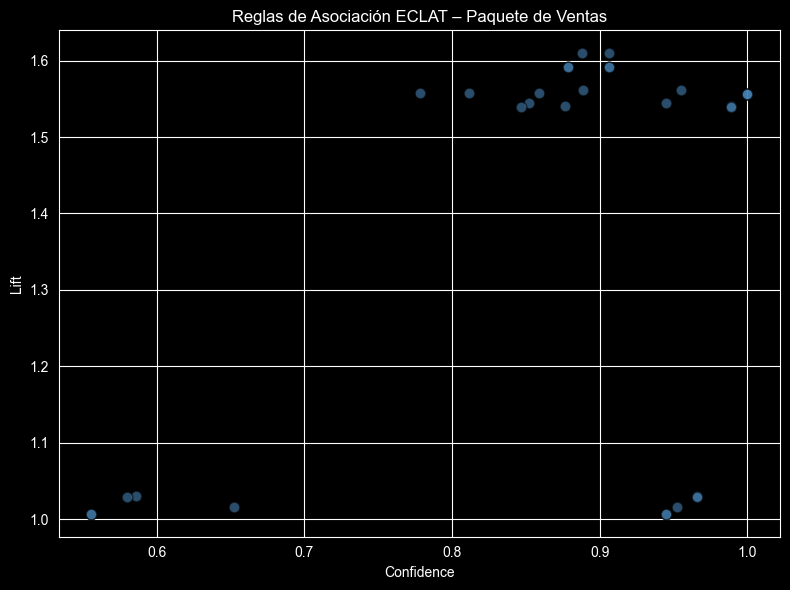

In [10]:
# Scatter plot de confidence vs lift
plt.figure(figsize=(8, 6))
plt.scatter(df_ar_paquete["confidence"], df_ar_paquete["lift"],
            alpha=0.6, c="steelblue", edgecolors="k", s=60)
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Reglas de Asociación ECLAT – Paquete de Ventas")
plt.tight_layout()
plt.show()

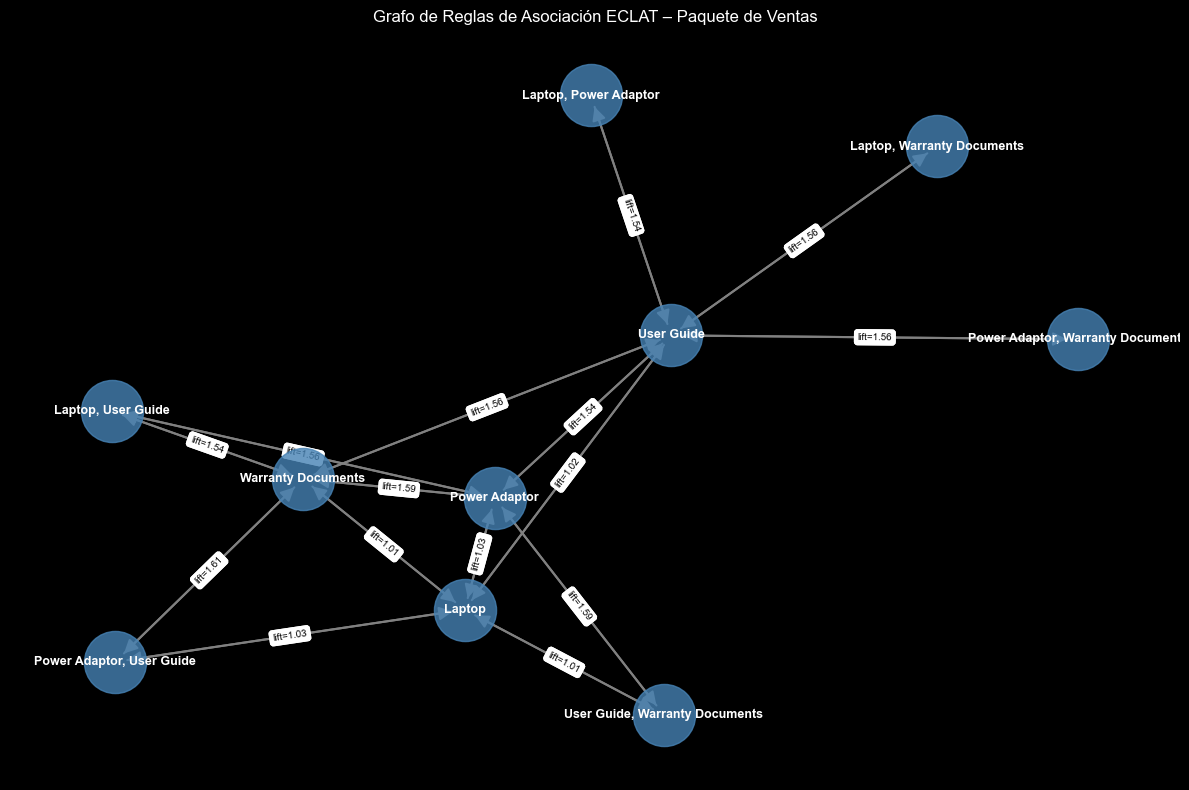

In [11]:
# Visualización de reglas como grafo de red
G = nx.DiGraph()
for _, row in df_ar_paquete.iterrows():
    ant = ", ".join(sorted(row["antecedents"]))
    con = ", ".join(sorted(row["consequents"]))
    G.add_edge(ant, con, weight=row["lift"])

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=2000, node_color="steelblue", alpha=0.8)
nx.draw_networkx_labels(G, pos, font_size=9, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True,
                       arrowsize=20, width=1.5)
edge_labels = {(u, v): f"lift={d['weight']:.2f}" for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title("Grafo de Reglas de Asociación ECLAT – Paquete de Ventas")
plt.axis("off")
plt.tight_layout()
plt.show()

## ECLAT con columna Características

In [12]:
df_paquete_caract = datos[["Caracteristicas"]]
df_paquete_caract.head()

,Caracteristicas
0,"Off Black,Gaming Laptop,Gaming,Intel,Core i9,3..."
1,"Off Black,Gaming Laptop,Gaming,Intel,Core i9,3..."
2,"Mica Silver,Gaming Laptop,Gaming,AMD,Ryzen 7 O..."
3,"Shadow Black,Gaming Laptop,Gaming,AMD,Ryzen 7 ..."
4,"Slate Grey,Thin and Light Laptop,Processing & ..."


In [13]:
df_paquete_caract.shape

(984, 1)

In [14]:
data_caract = list(
    df_paquete_caract["Caracteristicas"].apply(lambda x: [i.strip() for i in str(x).split(",")])
)
data_caract[:3]

[['Off Black',
  'Gaming Laptop',
  'Gaming',
  'Intel',
  'Core i9',
  '32 GB',
  'DDR5',
  'Windows 11 Home'],
 ['Off Black',
  'Gaming Laptop',
  'Gaming',
  'Intel',
  'Core i9',
  '32 GB',
  'DDR5',
  'Windows 11 Home'],
 ['Mica Silver',
  'Gaming Laptop',
  'Gaming',
  'AMD',
  'Ryzen 7 Octa Core',
  '16 GB',
  'DDR4',
  'Windows 11 Home']]

In [15]:
# Establezca un valor umbral para el soporte mínimo y ejecute ECLAT
frequent_itemsets_caract = run_eclat(data_caract, min_support=0.4)
df_itemsets_caract, _ = results_to_df(frequent_itemsets_caract, [])
df_itemsets_caract

,itemset,tamaño,support_count,support
2,DDR4,1,855,0.8689
4,Processing & Multitasking,1,772,0.7846
0,Intel,1,700,0.7114
5,8 GB,1,557,0.5661
3,Thin and Light Laptop,1,503,0.5112
6,Windows 10 Home,1,438,0.4451
1,Windows 11 Home,1,394,0.4004
13,"DDR4, Processing & Multitasking",2,660,0.6707
11,"DDR4, Intel",2,600,0.6098
16,"Intel, Processing & Multitasking",2,560,0.5691


In [16]:
# Reglas de asociación con umbral de confianza mínima
rules_caract = generate_rules(frequent_itemsets_caract, min_confidence=0.5)
_, df_ar_caract = results_to_df(frequent_itemsets_caract, rules_caract)
df_ar_caract

,antecedents,consequents,support,confidence,lift
0,frozenset({8 GB}),frozenset({DDR4}),0.5376,0.9497,1.0930
1,"frozenset({8 GB, Processing & Multitasking})",frozenset({DDR4}),0.4207,0.9388,1.0804
2,frozenset({Windows 10 Home}),frozenset({DDR4}),0.4075,0.9155,1.0537
3,frozenset({Thin and Light Laptop}),frozenset({Processing & Multitasking}),0.4644,0.9085,1.1580
4,frozenset({Thin and Light Laptop}),frozenset({DDR4}),0.4411,0.8628,0.9930
5,frozenset({Intel}),frozenset({DDR4}),0.6098,0.8571,0.9865
6,frozenset({Processing & Multitasking}),frozenset({DDR4}),0.6707,0.8549,0.9839
7,"frozenset({Processing & Multitasking, Intel})",frozenset({DDR4}),0.4807,0.8446,0.9721
8,frozenset({Intel}),frozenset({Processing & Multitasking}),0.5691,0.8000,1.0196
9,frozenset({8 GB}),frozenset({Processing & Multitasking}),0.4482,0.7917,1.0091


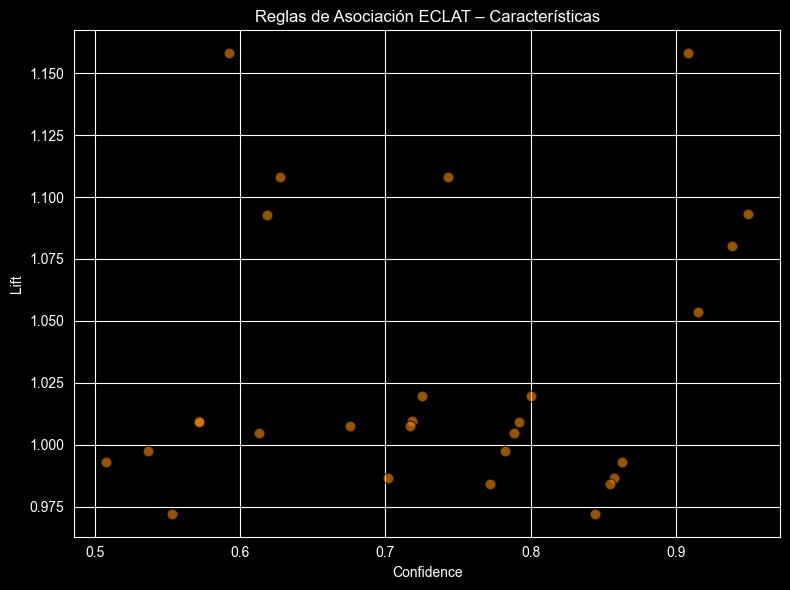

In [17]:
# Scatter plot de confidence vs lift
plt.figure(figsize=(8, 6))
plt.scatter(df_ar_caract["confidence"], df_ar_caract["lift"],
            alpha=0.6, c="darkorange", edgecolors="k", s=60)
plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Reglas de Asociación ECLAT – Características")
plt.tight_layout()
plt.show()

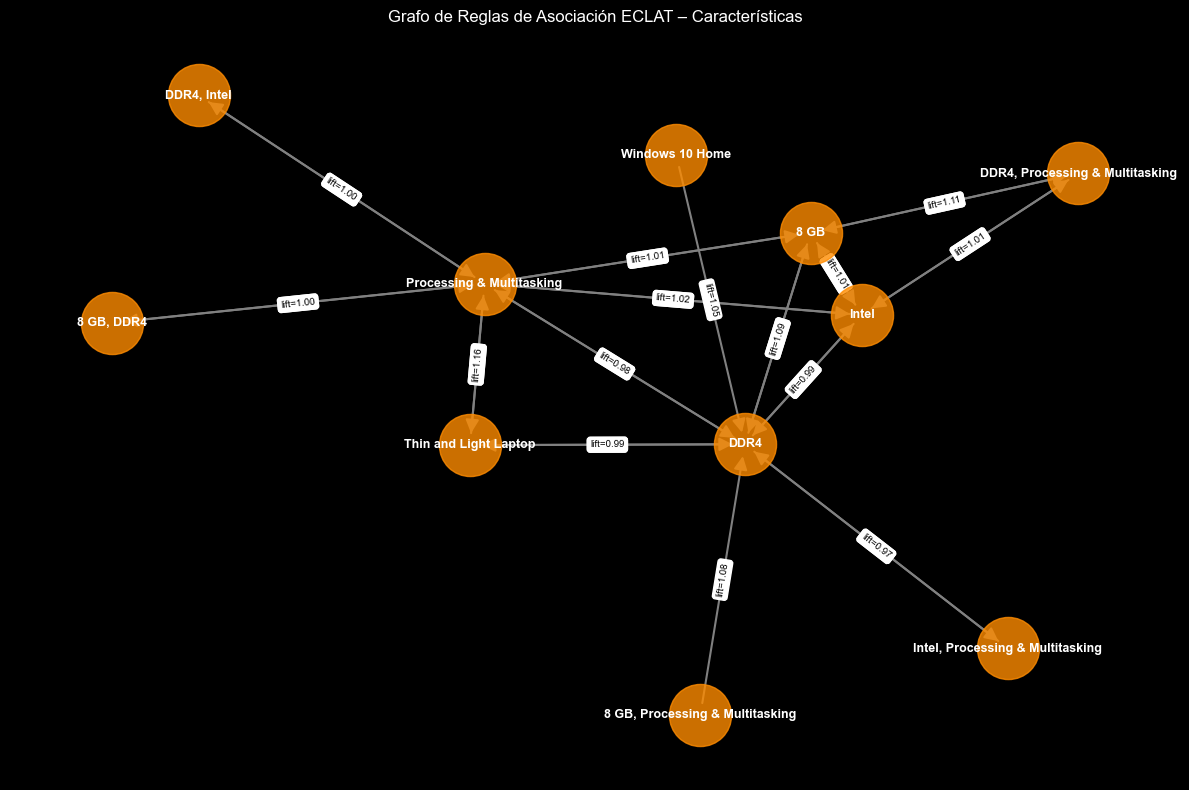

In [18]:
# Visualización de reglas como grafo de red
G2 = nx.DiGraph()
for _, row in df_ar_caract.iterrows():
    ant = ", ".join(sorted(row["antecedents"]))
    con = ", ".join(sorted(row["consequents"]))
    G2.add_edge(ant, con, weight=row["lift"])

plt.figure(figsize=(12, 8))
pos2 = nx.spring_layout(G2, seed=42)
nx.draw_networkx_nodes(G2, pos2, node_size=2000, node_color="darkorange", alpha=0.8)
nx.draw_networkx_labels(G2, pos2, font_size=9, font_color="white", font_weight="bold")
nx.draw_networkx_edges(G2, pos2, edge_color="gray", arrows=True,
                       arrowsize=20, width=1.5)
edge_labels2 = {(u, v): f"lift={d['weight']:.2f}" for u, v, d in G2.edges(data=True)}
nx.draw_networkx_edge_labels(G2, pos2, edge_labels=edge_labels2, font_size=7)
plt.title("Grafo de Reglas de Asociación ECLAT – Características")
plt.axis("off")
plt.tight_layout()
plt.show()